# Phase 4: Forecasting Monthly Expenses
In this notebook we build a linear regression model to forecast 
monthly expenses using historical spending data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

sns.set_theme(style='whitegrid')

# Load cleaned data
df = pd.read_csv('../data/cleaned_finance_data.csv')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1500, 9)


## Step 1: Prepare the data for modelling
We aggregate expenses by month and use the month number as our feature 
to predict total monthly spending.

In [2]:
# Filter expenses only
expenses = df[df['Type'] == 'Expense']

# Aggregate total expenses per month
monthly_expenses = expenses.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly_expenses.columns = ['Year', 'Month', 'Total_Expenses']

# Create a sequential month number for modelling (1, 2, 3... across all years)
monthly_expenses = monthly_expenses.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly_expenses['Month_Number'] = range(1, len(monthly_expenses) + 1)

print("Monthly expenses prepared:")
print(monthly_expenses.head(10))
print("\nTotal months:", len(monthly_expenses))

Monthly expenses prepared:
   Year  Month  Total_Expenses  Month_Number
0  2020      1        16061.16             1
1  2020      2        16814.10             2
2  2020      3        13581.81             3
3  2020      4        14010.45             4
4  2020      5        16528.08             5
5  2020      6        19572.88             6
6  2020      7        23916.34             7
7  2020      8        29976.82             8
8  2020      9        15608.36             9
9  2020     10        18337.37            10

Total months: 60


## Step 2: Split data into training and test sets

In [3]:
# Features and target
X = monthly_expenses[['Month_Number']]
y = monthly_expenses['Total_Expenses']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 48
Test samples: 12


## Step 3: Train the model

In [4]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"\nThis means for every month that passes, expenses change by ${model.coef_[0]:.2f}")

Model trained successfully!
Coefficient: -24.29
Intercept: 18577.51

This means for every month that passes, expenses change by $-24.29


## Step 4: Evaluate the model

In [5]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Model Evaluation:")
print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"\nOn average the model's predictions are off by ${mae:,.2f} per month")

Model Evaluation:
Mean Absolute Error (MAE):  $3,420.24
Root Mean Squared Error (RMSE): $4,328.71

On average the model's predictions are off by $3,420.24 per month


## Step 5: Visualise actual vs predicted expenses

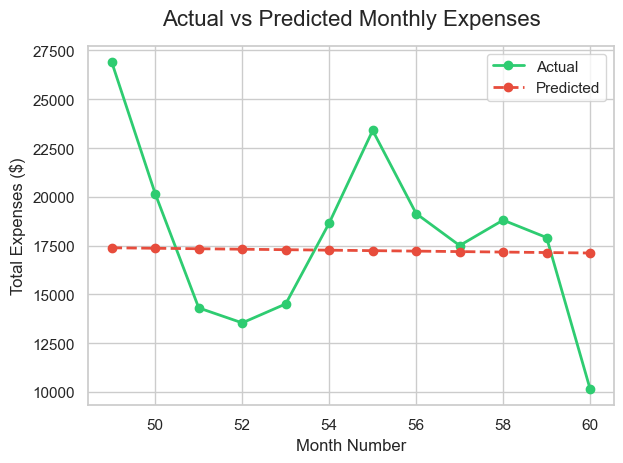

Chart 5 saved!


In [6]:
fig, ax = plt.subplots()

# Plot actual vs predicted
ax.plot(X_test['Month_Number'], y_test.values, 
        label='Actual', color='#2ecc71', linewidth=2, marker='o')
ax.plot(X_test['Month_Number'], y_pred, 
        label='Predicted', color='#e74c3c', linewidth=2, linestyle='--', marker='o')

ax.set_title('Actual vs Predicted Monthly Expenses', fontsize=16, pad=15)
ax.set_xlabel('Month Number', fontsize=12)
ax.set_ylabel('Total Expenses ($)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../data/chart5_actual_vs_predicted.png', dpi=150)
plt.show()
print("Chart 5 saved!")

In [7]:
# Forecast the next 6 months beyond our dataset
last_month = monthly_expenses['Month_Number'].max()
future_months = pd.DataFrame({'Month_Number': range(last_month + 1, last_month + 7)})
future_predictions = model.predict(future_months)

print("6 Month Expense Forecast:")
for i, pred in enumerate(future_predictions, 1):
    print(f"  Month {last_month + i}: ${pred:,.2f}")

6 Month Expense Forecast:
  Month 61: $17,095.90
  Month 62: $17,071.61
  Month 63: $17,047.33
  Month 64: $17,023.04
  Month 65: $16,998.75
  Month 66: $16,974.46


## Summary

- Built a linear regression model to forecast monthly expenses
- Trained on 48 months, tested on 12 months (80/20 split)
- Model Performance:
    - MAE: $3,420 — average prediction error per month
    - RMSE: $4,328 — slightly higher due to volatile months
- Forecasted expenses for the next 6 months averaging ~$17,000/month
- The model captures the overall downward trend but the high volatility 
  in actual spending suggests a more advanced model (ARIMA, Random Forest) 
  could improve accuracy in future iterations